In [1]:
import pandas as pd    # For loading and handling data
import seaborn as sns  # For visualization
import matplotlib.pyplot as plt  # For plotting

In [6]:
from google.colab import files
uploaded = files.upload()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [7]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:

df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [12]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [15]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


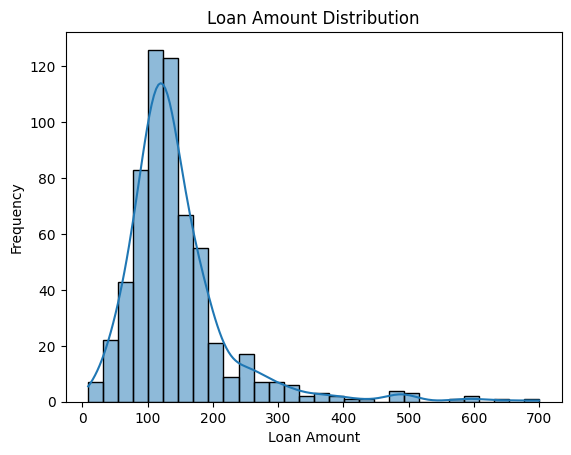

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['LoanAmount'], kde=True, bins=30)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

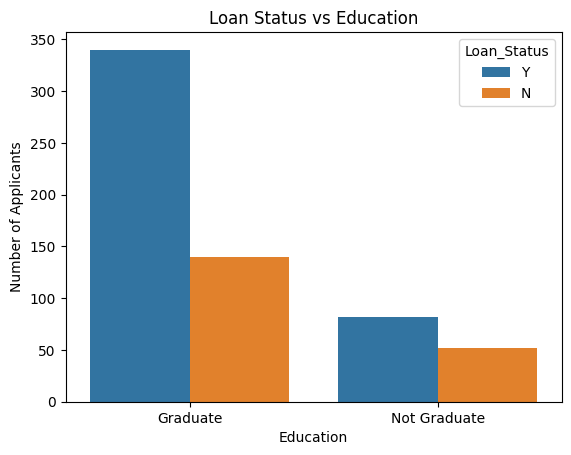

In [21]:

sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Loan Status vs Education")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.show()

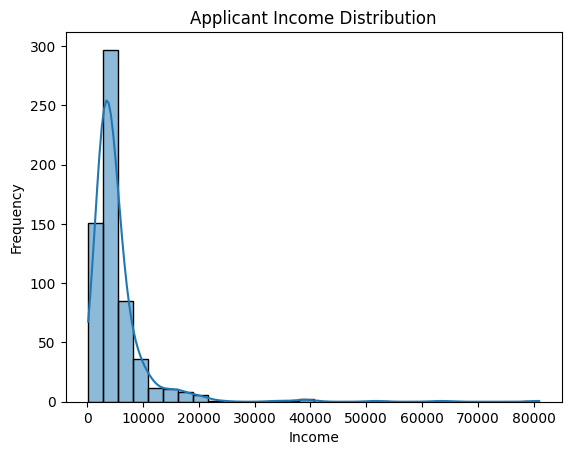

In [22]:

sns.histplot(df['ApplicantIncome'], bins=30, kde=True)
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

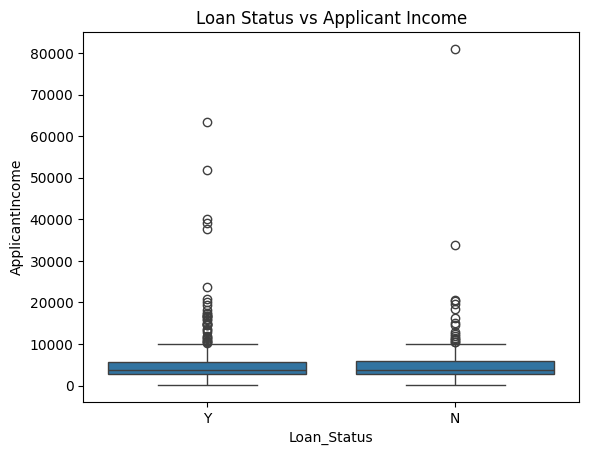

In [23]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Loan Status vs Applicant Income")
plt.show()

In [24]:

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})


df = pd.get_dummies(df, columns=['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents'], drop_first=True)

df.head()

,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Dependents_1,Dependents_2,Dependents_3+
0,LP001002,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,True,False,False,False
1,LP001003,4583,1508.0,128.0,360.0,1.0,0,True,True,False,False,False,False,True,False,False
2,LP001005,3000,0.0,66.0,360.0,1.0,1,True,True,False,True,False,True,False,False,False
3,LP001006,2583,2358.0,120.0,360.0,1.0,1,True,True,True,False,False,True,False,False,False
4,LP001008,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,True,False,False,False


In [25]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:

df = df.drop('Loan_ID', axis=1)

In [32]:
print(df.columns)

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Gender_Male',
       'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban', 'Dependents_1',
       'Dependents_2', 'Dependents_3+'],
      dtype='object')


In [33]:

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [34]:

X = df.drop('Loan_Status', axis=1)


y = df['Loan_Status']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:

df['Loan_Status'].isnull().sum()

np.int64(614)

In [38]:

df = df.dropna(subset=['Loan_Status'])

In [39]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [40]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7154471544715447
Decision Tree Confusion Matrix:
 [[21 22]
 [13 67]]
